**Created by Tahim Bhuiya**

**08/26/2026**

**Gradient descent learning in Python:**

(a) Create class NeuralNetwork(): that creates a single neuron with a linear activation, train it using gradient descent learning. This class should have the following function:

i. def __init__(self, learning_r): that initializes a 3x1 weight vector randomly and initializes the learning rate to learning_r. Also, it creates a history variable that saves the weights and the training cost after each epoch (i.e., iteration).

ii. def sigmoid(self, x): that takes an input x, and applies the sigmoid function to return:

iii. def forward_propagation(self, inputs): that performs forward propagation by multiplying the inputs by the neuron weights, uses sigmoid activation function and then generates the output.


iv. def train(self, inputs_train, labels_train, num_train_iterations): that performs the gradient descent learning rule for num_train_iterations times using the inputs and labels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class NeuralNetwork(object):

    # i. __init__
    def __init__(self, learning_r):
        np.random.seed(1)

        # 3x1 weight vector (2 inputs + bias)
        self.weight_matrix = 2 * np.random.random((3,1)) - 1

        # learning rate
        self.l_rate = learning_r

        # history of weights and cost
        self.history_weights = []
        self.history_cost = []

    # ii. sigmoid activation function
    def sigmoid(self, x):
        return 1/(1 + np.exp(-x))

    # iii. forward propagation
    def forward_propagation(self, inputs):
        outs = np.dot(inputs, self.weight_matrix)
        return self.sigmoid(outs)

    # iv. training with gradient descent
    def train(self, inputs_train, labels_train, num_train_iterations):

        N = inputs_train.shape[0]

        for iteration in range(num_train_iterations):

            # forward pass
            outputs = self.forward_propagation(inputs_train)

            # error
            error = labels_train - outputs

            # gradient descent adjustment
            adjustment = (self.l_rate/N) * np.dot(inputs_train.T, error) #transpose inputs_train

            # update weights
            self.weight_matrix += adjustment

            # cost function
            cost = (1/(2*N)) * np.sum(error**2)

            # save history
            self.history_cost.append(cost)
            self.history_weights.append(self.weight_matrix.copy())


(b) Use the gradient descent rule to train a single neuron on the datapoints given below:

i. Create an np array of a shape 10x2 that contains the inputs, and another array with a shape 10x1 that contains the labels.

ii. Plot the given data points with two different markers for each group.

iii. Add the bias to the inputs array to have a 10x3 shape.

iv. Create the network with one neuron using the class NeuralNetwork() with learning rate of 1 then train it using train (inputs, labels, 50) function.

In [2]:
# i. create arrays
# inputs (10x2)
inputs = np.array([
[1,1],
[1,0],
[0,1],
[0.5,-1],
[0.5,3],
[0.7,2],
[-1,0],
[-1,1],
[2,0],
[0,0]
])

# labels (10x1)
labels = np.array([
[1],
[1],
[0],
[0],
[1],
[1],
[0],
[0],
[1],
[0]
])

In [3]:
# plotting function that will be used
def plot_points(inputs, labels, classes):
    # Check for bias column (all 1s in first column)
    if inputs.shape[1] == 3 and np.all(inputs[:,0] == 1):
        x_col, y_col = 1, 2
    else:
        x_col, y_col = 0, 1

    # Class 0 points
    plt.plot(inputs[labels[:,0] == classes[0], x_col],
             inputs[labels[:,0] == classes[0], y_col],
             'rx', label=f'Class {classes[0]}')

    # Class 1 points
    plt.plot(inputs[labels[:,0] == classes[1], x_col],
             inputs[labels[:,0] == classes[1], y_col],
             'g^', label=f'Class {classes[1]}')

    plt.xlabel('x1 (Feature 1)')
    plt.ylabel('x2 (Feature 2)')
    plt.legend()

Text(0.5, 1.0, 'Plotted Points for Each Class')

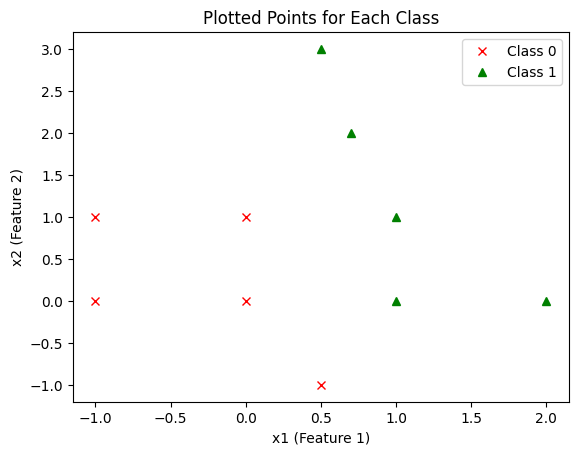

In [4]:
# ii. plot given data
classes = [0, 1]

# plot the datapoints
plot_points(inputs, labels, classes)
plt.title("Plotted Points for Each Class")

In [5]:
# iii. add bias
bias = np.ones((inputs.shape[0],1))
inputs=np.append(bias,inputs,axis=1)
print(inputs.shape)

(10, 3)


In [6]:
# iv. create network
nn = NeuralNetwork(1)

print('Random weights at start of training:')
print(nn.weight_matrix)

nn.train(inputs, labels, 50)

print("Final Weights:")
print(nn.weight_matrix)

Random weights at start of training:
[[-0.16595599]
 [ 0.44064899]
 [-0.99977125]]
Final Weights:
[[-2.16960572]
 [ 3.46870407]
 [ 1.34808305]]


(c) Use the trained weights and plot the final classifier line.

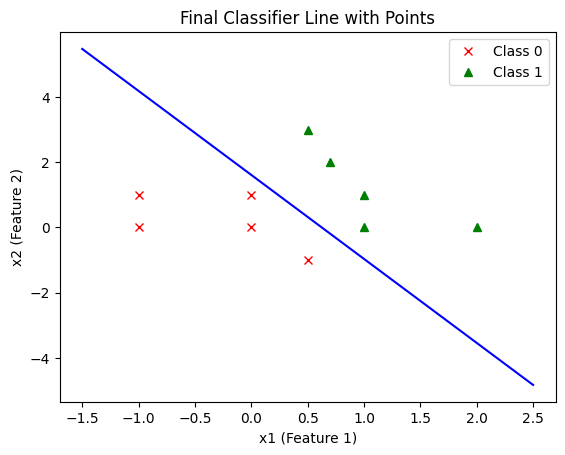

In [7]:
# Plot points
plot_points(inputs, labels, classes)

# Plot classifier line
w = nn.weight_matrix
x_vals = np.linspace(-1.5, 2.5, 50)
y_vals = -(w[0] + w[1]*x_vals) / w[2]
plt.plot(x_vals, y_vals, 'b-', label='Classifier Line')

plt.title("Final Classifier Line with Points")
plt.show()

(d) Plot the training cost (i.e., the learning curve) for all the epochs.

In [8]:
#plotting function that will be used to show learning curves
def plot_cost_func(J, iterations):
    plt.plot(J)
    plt.xlabel("Iterations")
    plt.ylabel("Cost J")
    plt.title("Learning Curve")
    plt.show()

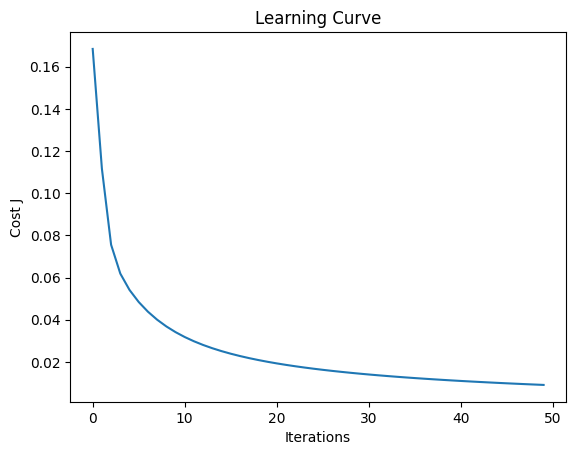

In [9]:
plot_cost_func(nn.history_cost, len(nn.history_cost))

(e) Repeat step (b.iv) with the learning rates of 0.5, 0.1, and 0.01. Plot the final classifier line and the learning curve for each learning rate.

Learning rate: 0.5
Random weights at start of training:
[[-0.16595599]
 [ 0.44064899]
 [-0.99977125]]
Final Weights:
[[-1.47953369]
 [ 2.56651734]
 [ 1.08127652]]


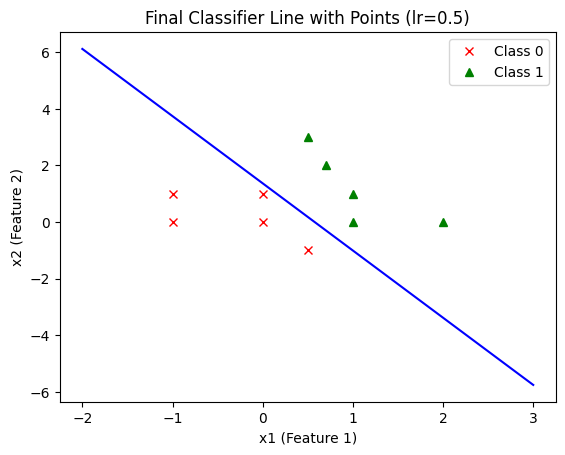

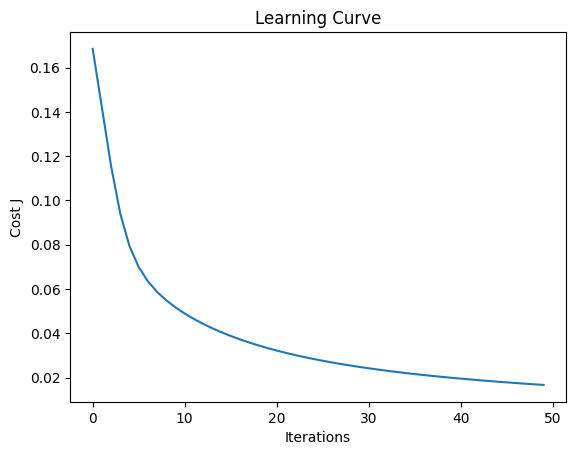

Learning rate: 0.1
Random weights at start of training:
[[-0.16595599]
 [ 0.44064899]
 [-0.99977125]]
Final Weights:
[[-0.28643485]
 [ 1.29840869]
 [ 0.34286026]]


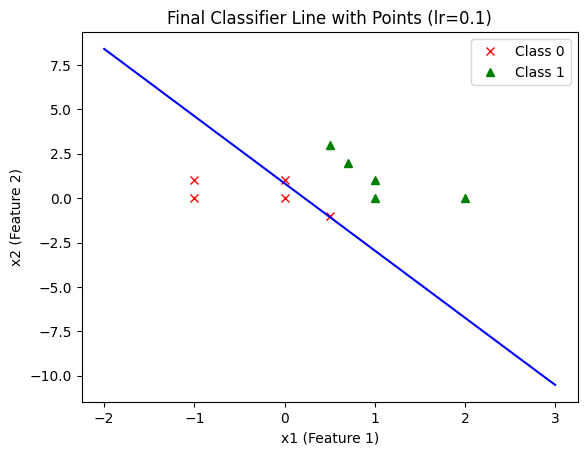

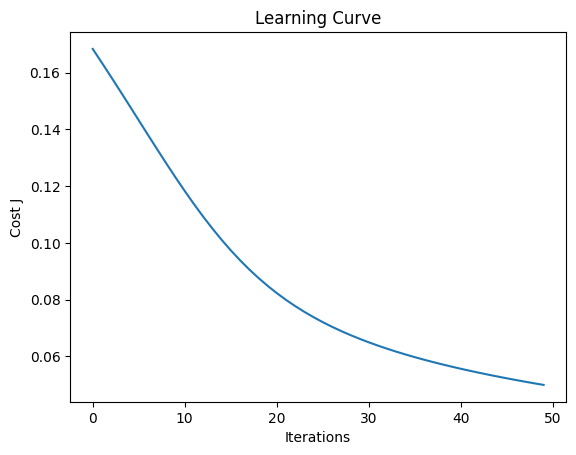

Learning rate: 0.01
Random weights at start of training:
[[-0.16595599]
 [ 0.44064899]
 [-0.99977125]]
Final Weights:
[[-0.1122277 ]
 [ 0.58096448]
 [-0.73483257]]


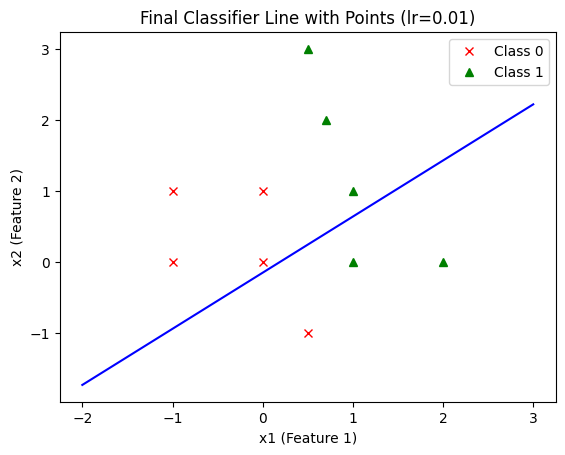

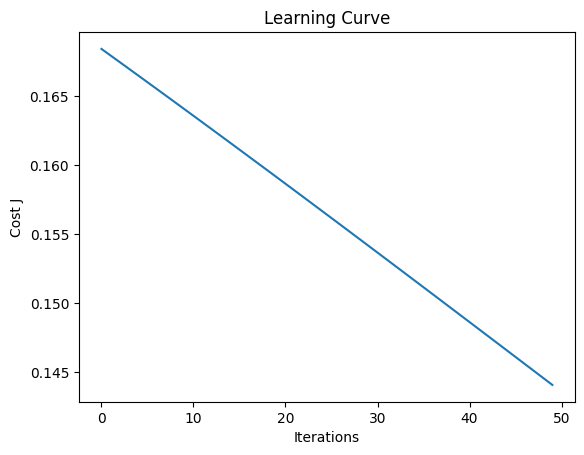

In [10]:
rates = [0.5, 0.1, 0.01]
classes = [0, 1]

for r in rates:
    nn = NeuralNetwork(r)
    print(f"Learning rate: {r}")
    print('Random weights at start of training:')
    print(nn.weight_matrix)

    # Train
    nn.train(inputs, labels, 50)
    print("Final Weights:")
    print(nn.weight_matrix)

    plot_points(inputs, labels, classes)  

    # Plot the classifier line
    w = nn.weight_matrix
    x_vals = np.linspace(-2, 3, 100)
    y_vals = -(w[0] + w[1]*x_vals) / w[2]
    plt.plot(x_vals, y_vals, 'b-', label=f'Classifier Line (lr={r})')

    plt.title(f"Final Classifier Line with Points (lr={r})")
    plt.show()  # show points + line

    plot_cost_func(nn.history_cost, len(nn.history_cost))

(f) What behavior do you observe from the learning curves with the different learning rates? Explain your observations. Which learning rate is more suitable? Explain.


**What behavior do you observe from the learning curves with the different learning rates? Explain your observations.**